# E3: Counterfactual Simulatability

**Research question:** Do NLEs help an LLM judge correctly predict *which direction* the model's output will change when top-K features are perturbed?

## Design

For each test instance:
1. Identify top-K features by absolute SHAP value (K=3)
2. Perturb those features using feature-specific rules:
   - **Lag features** (lag_1–lag_7): ±25% of the feature's own value (random direction)
   - **weekofyear**: ±13 weeks (random direction), clamped to [1, 52]
   - **holiday_week_count**: +2 (always increase)
3. Get XGBoost prediction for the perturbed instance
4. Judge sees original instance (with or without NLE) + perturbation plan
5. Judge predicts: will model output be higher, lower, or similar (within 5%)?

| Condition | Features | SHAP (X) | Metrics (T) | NLE (E) |
|-----------|:--:|:--:|:--:|:--:|
| X | ✓ | ✓ | ✓ | ✗ |
| E+X | ✓ | ✓ | ✓ | ✓ |

SHAP values and metrics are always included — they are essential context, and the NLE was generated from them.

**2×2 generator×judge design:** For the E+X condition, both GPT-4o and DeepSeek-R1 NLEs are evaluated by both judges (4 combinations). The X condition has no generator dimension — just 2 judges each.

## Judgment count

- X condition: N × 2 judges
- E+X condition: N × 2 generators × 2 judges
- **Pilot (N=15):** 15×2 + 15×2×2 = 30 + 60 = **90**
- **Full (N=60):** 60×2 + 60×2×2 = 120 + 240 = **360**

## Hypotheses

- H3a: NLEs help direction task (they encode causal feature-output relationships)
- H3b: NLEs have no effect (the quality-usefulness gap extends to causal reasoning)

## Statistical plan

- **Primary:** Direction accuracy (% correct) by condition
- **Key contrast:** X vs E+X (does NLE help on top of SHAP values?)
- **Secondary:** Confusion matrix (higher/lower/similar), confidence analysis
- **95% CI:** Wilson interval
- **Pilot (N=15) → effect size → power check → Full (N=60)**

## 0. Setup

In [1]:
import os
import sys
import asyncio
import json
import re
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
import matplotlib.pyplot as plt

import utils

# ── Toggle: pilot vs full ──────────────────────────────────────────
PILOT_MODE = False   # Set False for full experiment
N = 15 if PILOT_MODE else 60
RANDOM_SEED = 42
K = 3  # Top-K features to perturb
DIRECTION_THRESHOLD = 5.0  # % change threshold for 'similar'
# ───────────────────────────────────────────────────────────────────

# Override from run_all.py script
if os.environ.get('EXPERIMENT_N'):
    N = int(os.environ['EXPERIMENT_N'])
    PILOT_MODE = N < 60

RESULTS_DIR = utils.RESULTS_DIR / 'E3'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 2 conditions: structured info only vs structured + NLE
CONDITIONS = [
    {'name': 'X',   'nle': False},
    {'name': 'E+X', 'nle': True},
]

VALID_DIRECTIONS = {'higher', 'lower', 'similar'}

mode_str = f'PILOT (N={N})' if PILOT_MODE else f'FULL (N={N})'
print(f'E3 Counterfactual Simulatability — {mode_str}')
print(f'Conditions: {[c["name"] for c in CONDITIONS]}')

E3 Counterfactual Simulatability — FULL (N=60)
Conditions: ['X', 'E+X']


## 1. Load data and build counterfactual pairs

In [2]:
# Load test instances with SHAP values
model = utils.load_xgb_model()
test_df = utils.build_test_with_shap(model)
test_df['error_bucket'] = test_df['pct_error'].apply(utils.pct_error_to_bucket)

# Load NLE cache (120 rows: 60 × 2 generators)
nle_cache = utils.load_nle_cache()

print(f'Test instances: {len(test_df)}')
print(f'NLE cache: {len(nle_cache)} rows ({nle_cache["generator"].value_counts().to_dict()})')

Test instances: 60
NLE cache: 120 rows ({'gpt': 60, 'deepseek': 60})


In [3]:
# Build counterfactual pairs for ALL 60 instances
# Perturbation rules per feature type:
#   - lag_1..lag_7: ±25% of the feature's own value (random direction)
#   - weekofyear:   ±13 weeks (random direction), clamped to [1, 52]
#   - holiday_week_count: always +2
rng = np.random.default_rng(RANDOM_SEED)
cf_pairs = []

LAG_FEATURES = [f for f in utils.FEATURES if f.startswith('lag_')]

def perturb_feature(feat: str, value: float, rng) -> float:
    """Apply feature-specific perturbation."""
    if feat in LAG_FEATURES:
        direction = rng.choice([-1, 1])
        return value * (1 + direction * 0.25)
    elif feat == 'weekofyear':
        direction = rng.choice([-1, 1])
        new_val = value + direction * 13
        return float(np.clip(new_val, 1, 52))
    elif feat == 'holiday_week_count':
        return value + 2
    else:
        # Fallback: ±25%
        direction = rng.choice([-1, 1])
        return value * (1 + direction * 0.25)


for idx, row in test_df.iterrows():
    top_features = utils.get_top_k_shap_features(row, k=K)

    perturbed_row = row.copy()
    for f in top_features:
        perturbed_row[f] = perturb_feature(f, row[f], rng)

    X_pert = pd.DataFrame([perturbed_row[utils.FEATURES]])
    pred_orig = float(row['prediction'])
    pred_pert = float(model.predict(X_pert)[0])

    pct_change = (pred_pert - pred_orig) / pred_orig * 100
    if abs(pct_change) < DIRECTION_THRESHOLD:
        gt_direction = 'similar'
    elif pct_change > 0:
        gt_direction = 'higher'
    else:
        gt_direction = 'lower'

    cf_pairs.append({
        'orig_idx': idx,
        'DateTime': row['DateTime'],
        'top_features': json.dumps(top_features),
        'pred_orig': pred_orig,
        'pred_pert': pred_pert,
        'pct_change': pct_change,
        'gt_direction': gt_direction,
        'true_value': float(row['True_Value']),
        'pct_error': float(row['pct_error']),
        'error_bucket': row['error_bucket'],
        'shap_base_value': float(row['shap_base_value']),
        **{f'orig_{f}': float(row[f]) for f in utils.FEATURES},
        **{f'pert_{f}': float(perturbed_row[f]) for f in utils.FEATURES},
        **{f'shap_{f}': float(row[f'shap_{f}']) for f in utils.FEATURES},
    })

cf_df = pd.DataFrame(cf_pairs)
print(f'Built {len(cf_df)} counterfactual pairs')
print(f'\nDirection distribution (ground truth):')
print(cf_df['gt_direction'].value_counts())
print(f'\nPct change range: [{cf_df["pct_change"].min():.1f}%, {cf_df["pct_change"].max():.1f}%]')
print(f'\nExample perturbation (instance 0):')
top0 = json.loads(cf_df.iloc[0]['top_features'])
for f in top0:
    orig_v = cf_df.iloc[0][f'orig_{f}']
    pert_v = cf_df.iloc[0][f'pert_{f}']
    print(f'  {f}: {orig_v:.2f} → {pert_v:.2f}')

Built 60 counterfactual pairs

Direction distribution (ground truth):
gt_direction
higher     28
lower      24
similar     8
Name: count, dtype: int64

Pct change range: [-33.2%, 69.3%]

Example perturbation (instance 0):
  lag_6: 137.85 → 103.38
  lag_1: 166.27 → 207.84
  lag_7: 129.44 → 161.80


In [4]:
# Sample N instances (stratified by gt_direction)
if N < len(cf_df):
    sampled_indices = []
    for direction, group in cf_df.groupby('gt_direction'):
        n_from_group = max(1, round(N * len(group) / len(cf_df)))
        sampled_indices.extend(group.sample(min(len(group), n_from_group),
                                            random_state=RANDOM_SEED).index.tolist())
    if len(sampled_indices) < N:
        remaining = [i for i in cf_df.index if i not in sampled_indices]
        extra = np.random.default_rng(RANDOM_SEED).choice(remaining, size=N - len(sampled_indices), replace=False)
        sampled_indices.extend(extra.tolist())
    sampled_indices = sampled_indices[:N]
    sample_cf = cf_df.loc[sampled_indices].copy()
else:
    sample_cf = cf_df.copy()

sample_cf = sample_cf.reset_index(drop=True)

print(f'Using {len(sample_cf)} counterfactual pairs')
print('Sample direction distribution:', sample_cf['gt_direction'].value_counts().to_dict())
print('orig_idx values (RowPos):', sorted(sample_cf['orig_idx'].tolist()))

Using 60 counterfactual pairs
Sample direction distribution: {'higher': 28, 'lower': 24, 'similar': 8}
orig_idx values (RowPos): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]


## 2. Build judge prompts

In [5]:
JUDGE_SYSTEM = """You are evaluating how a machine learning model's prediction would change if certain input features were modified.
You have limited background in machine learning and statistics — you understand basic concepts but are not an expert.

Your task: Given the original instance and a proposed feature change, predict whether the model's prediction will be HIGHER, LOWER, or SIMILAR compared to the original prediction.

Important: Think carefully about the case. Consider the feature values, their SHAP importances (which show each feature's contribution to the prediction), and the direction of change. Do not default to a "safe" middle-ground answer. Each perturbation has a specific directional effect — use the evidence to determine what it is.

Evaluation steps (think through each before giving your final answer):
1. Identify which features are being changed and note their current SHAP values
2. For each changed feature, determine the direction of change — is the new value higher or lower than the original?
3. Consider how the SHAP contribution might change
4. If multiple features are changed, think about their combined effect
5. If a natural language explanation is provided, you can use it to better understand the feature-prediction relationships
6. Estimate the net directional effect and whether it exceeds the 5% threshold

Direction definitions:
- higher: model prediction increases by more than 5% relative to the original
- lower: model prediction decreases by more than 5% relative to the original
- similar: model prediction changes by less than 5% in either direction

Confidence scale:
- 1 = Very uncertain about my assessment
- 2 = Somewhat uncertain
- 3 = Moderately confident
- 4 = Fairly confident
- 5 = Very certain about my assessment

You must respond with EXACTLY this JSON format and nothing else:
{
  "direction": "<one of: higher, lower, similar>",
  "confidence": <integer from 1 to 5>,
  "reasoning": "<one sentence explaining your choice>"
}"""

DOMAIN_CONTEXT = """The following is about time series data with a single-step ahead prediction, where the model predicts the next value in the time series based on previous observations.
Data Domain: Energy Consumption
Dataset Description:
- The dataset contains 2,075,259 measurements from a house in Sceaux, France (near Paris), Dec 2006–Nov 2010.
- Recorded at one-minute resolution, then resampled weekly.
- Lag_1..Lag_7 (previous 7 weeks of consumption in kWh), ISO week number and number of public holidays per week were added as features.
- Target: weekly electricity consumption (kWh)."""


def build_prompt(row: pd.Series, condition: dict, nle_text: str = '') -> str:
    """Build the judge prompt for a counterfactual pair."""
    parts = [DOMAIN_CONTEXT, '']

    parts.append(f'Model Used: XGBRegressor')
    parts.append(f'Model Performance:')
    parts.append(f'  - MAE: {utils.XGB_PERF["MAE"]:.3f}')
    parts.append(f'  - RMSE: {utils.XGB_PERF["RMSE"]:.3f}')
    parts.append(f'  - R²: {utils.XGB_PERF["R2"]:.3f}')

    parts.append(f'')
    parts.append(f'ORIGINAL INSTANCE:')
    parts.append(f'Prediction: {row["pred_orig"]:.2f} kWh')
    parts.append(f'')
    parts.append(f'Instance Features:')
    for f in utils.FEATURES:
        parts.append(f'{f}: {row[f"orig_{f}"]:.2f}')

    # SHAP values (always included in E3)
    parts.append(f'')
    parts.append(f'SHAP values (showing each feature\'s contribution to the prediction):')
    shap_pairs = [(f, row[f'shap_{f}']) for f in utils.FEATURES]
    shap_pairs.sort(key=lambda x: abs(x[1]), reverse=True)
    for feat, val in shap_pairs:
        parts.append(f'{feat}: {val:+.3f}')
    parts.append(f'The expected/base value for SHAP: {row["shap_base_value"]:.3f}')

    # Optional: NLE
    if condition['nle'] and nle_text:
        parts.append(f'')
        parts.append(f'Natural language explanation of this prediction:')
        parts.append(nle_text)

    # Perturbation info
    top_features = json.loads(row['top_features'])
    parts.append(f'')
    parts.append(f'PROPOSED FEATURE CHANGES:')
    parts.append(f'The following {len(top_features)} most important features are changed:')
    for f in top_features:
        parts.append(f'  {f}: {row[f"orig_{f}"]:.2f} → {row[f"pert_{f}"]:.2f}')

    parts.append(f'')
    parts.append(f'If these features change as described, will the model predict HIGHER, LOWER, or SIMILAR consumption compared to {row["pred_orig"]:.2f} kWh?')

    return '\n'.join(parts)


# Preview prompts
row0 = sample_cf.iloc[0]
orig_idx_0 = int(row0['orig_idx'])
print('=== SYSTEM PROMPT ===')
print(JUDGE_SYSTEM)
print()
print('=' * 60)
print('=== X condition (no NLE) ===')
print(build_prompt(row0, CONDITIONS[0]))
print()
print('=' * 60)
print('=== E+X condition — GPT NLE ===')
nle_gpt_0 = nle_cache[(nle_cache['RowPos'] == orig_idx_0) & (nle_cache['generator'] == 'gpt')]
nle_text_0 = nle_gpt_0.iloc[0]['Explanation'] if len(nle_gpt_0) else '(no NLE found)'
print(build_prompt(row0, CONDITIONS[1], nle_text_0))

=== SYSTEM PROMPT ===
You are evaluating how a machine learning model's prediction would change if certain input features were modified.
You have limited background in machine learning and statistics — you understand basic concepts but are not an expert.

Your task: Given the original instance and a proposed feature change, predict whether the model's prediction will be HIGHER, LOWER, or SIMILAR compared to the original prediction.

Important: Think carefully about the case. Consider the feature values, their SHAP importances (which show each feature's contribution to the prediction), and the direction of change. Do not default to a "safe" middle-ground answer. Each perturbation has a specific directional effect — use the evidence to determine what it is.

Evaluation steps (think through each before giving your final answer):
1. Identify which features are being changed and note their current SHAP values
2. For each changed feature, determine the direction of change — is the new value 

## 3. Response parsing

In [6]:
def parse_response(raw: str) -> dict:
    """Parse judge response into {direction, confidence, reasoning}."""
    # Try JSON extraction first
    match = re.search(r'\{[^{}]+\}', raw, re.DOTALL)
    if match:
        try:
            parsed = json.loads(match.group())
            direction = parsed.get('direction', '').lower().strip()
            if direction in VALID_DIRECTIONS:
                conf = parsed.get('confidence')
                if conf is not None:
                    try:
                        conf = int(conf)
                    except (ValueError, TypeError):
                        conf = None
                return {
                    'direction': direction,
                    'confidence': conf,
                    'reasoning': parsed.get('reasoning', ''),
                }
        except json.JSONDecodeError:
            pass

    # Fallback: keyword extraction
    raw_lower = raw.lower()
    for kw in ['similar', 'higher', 'lower']:
        if kw in raw_lower:
            return {'direction': kw, 'confidence': None, 'reasoning': raw[:200]}

    return {'direction': 'parse_error', 'confidence': None, 'reasoning': raw[:200]}

## 4. Run experiment

In [7]:
CACHE_PATH = RESULTS_DIR / ('pilot_results.csv' if PILOT_MODE else 'full_results.csv')

# Resume support — filter out error rows so they get retried
if CACHE_PATH.exists():
    existing = pd.read_csv(CACHE_PATH)
    # Drop rows that are errors/timeouts (raw_response starts with ERROR, or null in key columns)
    is_error = (
        existing['raw_response'].astype(str).str.startswith('ERROR') |
        existing['confidence'].isna() |
        existing['raw_response'].isna() |
        existing['predicted_direction'].isin(['error', 'parse_error'])
    )
    good = existing[~is_error]
    n_dropped = len(existing) - len(good)
    done_keys = set(zip(good['instance_idx'].astype(str),
                        good['condition'],
                        good['generator'],
                        good['judge']))
    results = good.to_dict('records')
    print(f'Resuming: {len(results)} valid judgments loaded, {n_dropped} error rows dropped for retry.')
else:
    done_keys = set()
    results = []


# Build NLE lookup: {(RowPos, generator) -> Explanation}
nle_lookup = {}
for _, nle_row in nle_cache.iterrows():
    nle_lookup[(int(nle_row['RowPos']), nle_row['generator'])] = nle_row['Explanation']


async def judge_one(orig_idx: int, row: pd.Series, condition: dict,
                    generator: str, judge: str) -> dict:
    """Single judgment call."""
    nle_text = ''
    if condition['nle']:
        nle_text = nle_lookup.get((orig_idx, generator), '')

    human_msg = build_prompt(row, condition, nle_text)

    if judge == 'gpt':
        success, result, retries, latency, err = await utils.async_call_gpt(
            JUDGE_SYSTEM, human_msg, temperature=0.0, max_tokens=200
        )
    else:
        success, result, retries, latency, err = await utils.async_call_deepseek(
            JUDGE_SYSTEM, human_msg, temperature=0.0, max_tokens=500
        )

    raw = (result or {}).get('text', '') if success else f'ERROR: {err}'
    parsed = parse_response(raw) if success else {'direction': 'error', 'confidence': None, 'reasoning': str(err)}

    return {
        'instance_idx': orig_idx,
        'condition': condition['name'],
        'generator': generator,
        'judge': judge,
        'has_nle': condition['nle'],
        'WeekEndDate': str(row['DateTime']),
        'pred_orig': float(row['pred_orig']),
        'pred_pert': float(row['pred_pert']),
        'pct_change': float(row['pct_change']),
        'top_features': row['top_features'],
        'true_direction': row['gt_direction'],
        'predicted_direction': parsed['direction'],
        'correct': int(parsed['direction'] == row['gt_direction']),
        'confidence': parsed['confidence'],
        'reasoning': parsed['reasoning'],
        'raw_response': raw[:500],
        'system_msg': JUDGE_SYSTEM,
        'human_msg': human_msg,
        'Duration_s': round(latency, 2) if success else None,
        'retries': retries if success else None,
    }


# Build task list
tasks = []

for _, row in sample_cf.iterrows():
    orig_idx = int(row['orig_idx'])
    for cond in CONDITIONS:
        if cond['nle']:
            # NLE condition: 2 generators × 2 judges = 4 calls
            for gen in ['gpt', 'deepseek']:
                for judge in ['gpt', 'deepseek']:
                    key = (str(orig_idx), cond['name'], gen, judge)
                    if key not in done_keys:
                        tasks.append(judge_one(orig_idx, row, cond, gen, judge))
        else:
            # No-NLE condition: no generator dimension, 2 judges
            for judge in ['gpt', 'deepseek']:
                key = (str(orig_idx), cond['name'], 'none', judge)
                if key not in done_keys:
                    tasks.append(judge_one(orig_idx, row, cond, 'none', judge))

print(f'Tasks to run: {len(tasks)}')
print(f'Already done:  {len(done_keys)}')

if tasks:
    desc = f'E3 {"Pilot" if PILOT_MODE else "Full"} ({len(tasks)} judgments)'
    new_results = await utils.run_async_tasks(tasks, desc=desc)
    results.extend(new_results)

    # Save immediately
    pd.DataFrame(results).to_csv(CACHE_PATH, index=False)
    print(f'Saved {len(results)} total judgments -> {CACHE_PATH}')
else:
    print('Nothing to run — all judgments cached.')

results_df = pd.DataFrame(results)
print(f'\nTotal judgments: {len(results_df)}')
print(results_df['condition'].value_counts())

Resuming: 360 valid judgments loaded, 0 error rows dropped for retry.
Tasks to run: 0
Already done:  360
Nothing to run — all judgments cached.

Total judgments: 360
condition
E+X    240
X      120
Name: count, dtype: int64


## 5. Analysis

In [8]:
# Load results from file (can re-run analysis independently of experiment)
CACHE_PATH = RESULTS_DIR / ('pilot_results.csv' if PILOT_MODE else 'full_results.csv')
df_res = pd.read_csv(CACHE_PATH)
df_valid = df_res[df_res['predicted_direction'].isin(VALID_DIRECTIONS)].copy()

print(f'Valid judgments: {len(df_valid)} / {len(df_res)} ({len(df_valid)/len(df_res):.1%})')
print(f'Conditions: {sorted(df_valid["condition"].unique())}')

# ── Accuracy by condition ──────────────────────────────────────────
acc = df_valid.groupby('condition')['correct'].agg(['mean', 'sum', 'count'])
acc.columns = ['accuracy', 'n_correct', 'n_total']

# Wilson CI
def wilson_ci(s, n, alpha=0.05):
    z = norm.ppf(1 - alpha/2)
    p = s / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    margin = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return center - margin, center + margin

acc['ci_lo'] = [wilson_ci(row.n_correct, row.n_total)[0] for _, row in acc.iterrows()]
acc['ci_hi'] = [wilson_ci(row.n_correct, row.n_total)[1] for _, row in acc.iterrows()]

print('\n=== Accuracy by condition ===')
print(acc.round(3))

# ── Key contrast: X vs E+X ─────────────────────────────────────────
x_only = df_valid[df_valid['condition'] == 'X']['correct']
e_x = df_valid[df_valid['condition'] == 'E+X']['correct']

if len(x_only) > 0 and len(e_x) > 0:
    u_stat, p_val = stats.mannwhitneyu(e_x, x_only, alternative='two-sided')
    from statsmodels.stats.proportion import proportion_effectsize
    h = proportion_effectsize(e_x.mean(), x_only.mean())
    print(f'\n=== Key contrast: X vs E+X ===')
    print(f'  X accuracy:   {x_only.mean():.3f} (n={len(x_only)})')
    print(f'  E+X accuracy: {e_x.mean():.3f} (n={len(e_x)})')
    print(f'  Diff:         {e_x.mean() - x_only.mean():+.3f}')
    print(f'  Mann-Whitney U={u_stat:.0f}, p={p_val:.4f}')
    print(f'  Cohen\'s h = {h:.3f}')

# ── Per-judge breakdown ────────────────────────────────────────────
print('\n=== Accuracy by condition × judge ===')
print(df_valid.groupby(['condition', 'judge'])['correct'].mean().unstack().round(3))

# ── Predicted direction distribution ───────────────────────────────
print('\n=== Predicted direction distribution by judge ===')
print(df_valid.groupby('judge')['predicted_direction'].value_counts().unstack(fill_value=0))

# ── Confusion matrix ───────────────────────────────────────────────
for cond_name in ['X', 'E+X']:
    cond_df = df_valid[df_valid['condition'] == cond_name]
    cm = pd.crosstab(cond_df['true_direction'], cond_df['predicted_direction'],
                     rownames=['True'], colnames=['Predicted'])
    print(f'\n--- Confusion matrix: {cond_name} ---')
    print(cm)

Valid judgments: 360 / 360 (100.0%)
Conditions: ['E+X', 'X']

=== Accuracy by condition ===
           accuracy  n_correct  n_total  ci_lo  ci_hi
condition                                            
E+X           0.579        139      240  0.516   0.64
X             0.533         64      120  0.444   0.62

=== Key contrast: X vs E+X ===
  X accuracy:   0.533 (n=120)
  E+X accuracy: 0.579 (n=240)
  Diff:         +0.046
  Mann-Whitney U=15060, p=0.4094
  Cohen's h = 0.092

=== Accuracy by condition × judge ===
judge      deepseek    gpt
condition                 
E+X           0.617  0.542
X             0.600  0.467

=== Predicted direction distribution by judge ===
predicted_direction  higher  lower  similar
judge                                      
deepseek                 82     73       25
gpt                      73     80       27

--- Confusion matrix: X ---
Predicted  higher  lower  similar
True                             
higher         31     19        6
lower          10  

In [9]:
if PILOT_MODE:
    # ── Power analysis: instance-level, paired design ──────────
    instance_acc = df_valid.groupby(['instance_idx', 'condition'])['correct'].mean().reset_index()
    pivot = instance_acc.pivot(index='instance_idx', columns='condition', values='correct')

    print('=== Per-instance accuracy by condition (pilot) ===')
    print(pivot.describe().round(3))

    if 'X' in pivot.columns and 'E+X' in pivot.columns:
        paired = pivot[['X', 'E+X']].dropna()
        diff = paired['E+X'] - paired['X']

        print(f'\n=== Key contrast: X vs E+X (paired, N={len(paired)} instances) ===')
        print(f'  Mean X accuracy per instance:   {paired["X"].mean():.3f}')
        print(f'  Mean E+X accuracy per instance: {paired["E+X"].mean():.3f}')
        print(f'  Mean paired difference:         {diff.mean():+.3f}')
        print(f'  Std of paired difference:       {diff.std():.3f}')

        if diff.std() > 0:
            d_paired = abs(diff.mean()) / diff.std()
        else:
            d_paired = 0.0
        print(f'  Cohen\'s d (paired):            {d_paired:.3f}')

        from scipy.stats import ttest_rel
        t_stat, p_val = ttest_rel(paired['E+X'], paired['X'])
        print(f'  Paired t-test: t={t_stat:.3f}, p={p_val:.4f}')

        from statsmodels.stats.power import TTestIndPower
        detectable_d = TTestIndPower().solve_power(nobs1=60, alpha=0.05, power=0.80)
        print(f'\n  Minimum detectable effect with N=60 (α=0.05, power=0.80): d={detectable_d:.3f}')

    print(f'\n→ To run full experiment: set PILOT_MODE = False and re-run.')
else:
    print('Full experiment mode — skipping power analysis.')

Full experiment mode — skipping power analysis.


## 6. Confidence analysis

In [10]:
conf_df = df_valid[df_valid['confidence'].notna()].copy()
conf_df['confidence'] = pd.to_numeric(conf_df['confidence'], errors='coerce')
conf_df = conf_df[conf_df['confidence'].notna()]

if len(conf_df) > 0:
    print('=== Mean confidence by condition × correctness ===')
    ct = conf_df.groupby(['condition', 'correct'])['confidence'].mean().unstack()
    ct.columns = ['Wrong', 'Correct']
    print(ct.round(2))

    # Overconfidence: wrong + confidence >= 4
    wrong = conf_df[conf_df['correct'] == 0]
    if len(wrong) > 0:
        overconf = wrong.groupby('has_nle')['confidence'].apply(lambda x: (x >= 4).mean())
        overconf.index = ['No NLE' if not v else 'With NLE' for v in overconf.index]
        print(f'\nOverconfidence rate (wrong + confidence >= 4):')
        print(overconf.round(3))

    # Mean confidence: NLE vs no-NLE
    print(f'\nMean confidence:')
    print(f'  No NLE:   {conf_df[~conf_df["has_nle"]]["confidence"].mean():.2f}')
    print(f'  With NLE: {conf_df[conf_df["has_nle"]]["confidence"].mean():.2f}')
else:
    print('No confidence data available.')

=== Mean confidence by condition × correctness ===
           Wrong  Correct
condition                
E+X         3.82     4.13
X           3.91     4.02

Overconfidence rate (wrong + confidence >= 4):
No NLE      0.768
With NLE    0.713
Name: confidence, dtype: float64

Mean confidence:
  No NLE:   3.97
  With NLE: 4.00


## 7. Visualisation

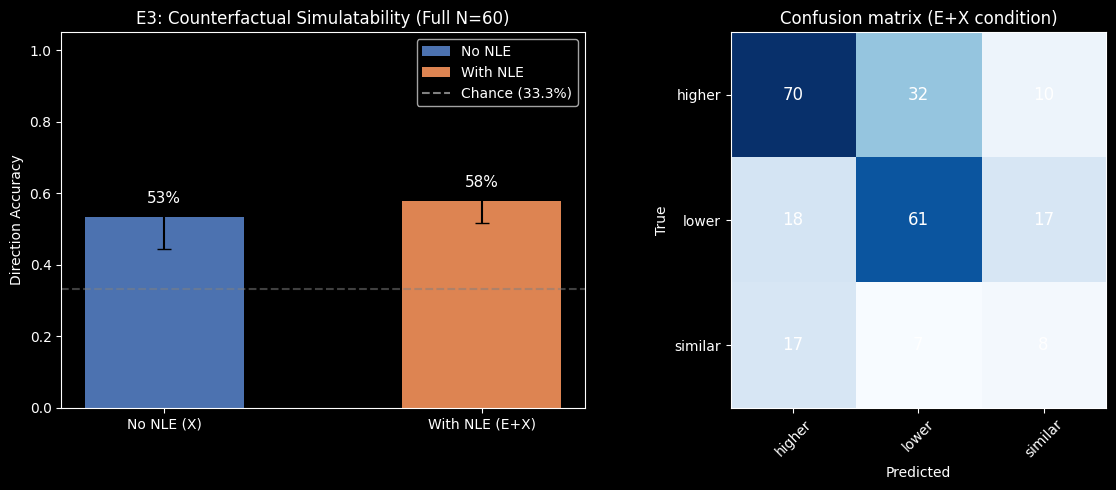

Figure saved: /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/E3/full_accuracy_by_condition.png


In [11]:
cond_order = ['X', 'E+X']
colors = ['#4C72B0', '#DD8452']

accs = [acc.loc[c, 'accuracy'] if c in acc.index else 0 for c in cond_order]
lo = [acc.loc[c, 'ci_lo'] if c in acc.index else 0 for c in cond_order]
hi = [acc.loc[c, 'ci_hi'] if c in acc.index else 0 for c in cond_order]
errs = [[accs[i] - lo[i], hi[i] - accs[i]] for i in range(len(cond_order))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: accuracy bar chart
bars = ax1.bar(['No NLE (X)', 'With NLE (E+X)'], accs, color=colors, width=0.5,
              yerr=np.array(errs).T, capsize=5, ecolor='black')
ax1.set_ylim(0, 1.05)
ax1.set_ylabel('Direction Accuracy')
mode_label = 'Pilot N=15' if PILOT_MODE else 'Full N=60'
ax1.set_title(f'E3: Counterfactual Simulatability ({mode_label})')
ax1.axhline(1/3, ls='--', color='gray', alpha=0.5, label='Chance (33.3%)')

for bar, a in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{a:.0%}', ha='center', va='bottom', fontsize=11)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='No NLE'),
    Patch(facecolor='#DD8452', label='With NLE'),
    plt.Line2D([0], [0], color='gray', ls='--', label='Chance (33.3%)')
]
ax1.legend(handles=legend_elements)

# Right: confusion matrix (E+X condition)
e_x_df = df_valid[df_valid['condition'] == 'E+X']
if len(e_x_df) > 0:
    dir_order = ['higher', 'lower', 'similar']
    cm = pd.crosstab(e_x_df['true_direction'], e_x_df['predicted_direction'],
                     rownames=['True'], colnames=['Predicted'])
    cm = cm.reindex(index=dir_order, columns=dir_order, fill_value=0)
    im = ax2.imshow(cm.values, cmap='Blues')
    ax2.set_xticks(range(len(dir_order)))
    ax2.set_yticks(range(len(dir_order)))
    ax2.set_xticklabels(dir_order, rotation=45)
    ax2.set_yticklabels(dir_order)
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')
    ax2.set_title('Confusion matrix (E+X condition)')
    for i in range(len(dir_order)):
        for j in range(len(dir_order)):
            ax2.text(j, i, cm.values[i, j], ha='center', va='center', fontsize=12)

plt.tight_layout()

fig_path = RESULTS_DIR / f'{"pilot" if PILOT_MODE else "full"}_accuracy_by_condition.png'
plt.savefig(fig_path, dpi=150)
plt.show()
print(f'Figure saved: {fig_path}')

## 8. Summary

In [12]:
# Save summary table
summary = acc.copy()
summary['ci'] = [f"[{row.ci_lo:.1%}, {row.ci_hi:.1%}]" for _, row in summary.iterrows()]
summary['has_nle'] = [c in ['E+X'] for c in summary.index]
summary.to_csv(RESULTS_DIR / f'{"pilot" if PILOT_MODE else "full"}_summary.csv')

print('=== E3 Summary ===')
print(summary[['accuracy', 'n_total', 'ci', 'has_nle']].round(3))
print()

if PILOT_MODE:
    print('NEXT: Review pilot results. If effect size is sufficient, set PILOT_MODE = False and re-run.')
else:
    print('Full experiment complete.')
    print(f'Results: {CACHE_PATH}')
    print(f'Summary: {RESULTS_DIR / "full_summary.csv"}')

=== E3 Summary ===
           accuracy  n_total              ci  has_nle
condition                                            
E+X           0.579      240  [51.6%, 64.0%]     True
X             0.533      120  [44.4%, 62.0%]    False

Full experiment complete.
Results: /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/E3/full_results.csv
Summary: /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/E3/full_summary.csv
